# First Load the .graphml files

In [3]:
from pathlib import Path
import networkx as nx

folder_path = Path(".\\asnr datasets")
print(folder_path.exists())


asnr_graphs = {}

for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)

    key_name = file_path.stem + ".graphml"

    asnr_graphs[key_name] = graph


True


### asnr_graphs are graphml filenames like "Network_n.graphml"

In [2]:
print(asnr_graphs.keys())

dict_keys(['Network_0.graphml', 'Network_1.graphml', 'Network_10.graphml', 'Network_100.graphml', 'Network_1000.graphml', 'Network_1001.graphml', 'Network_1002.graphml', 'Network_1003.graphml', 'Network_1004.graphml', 'Network_1005.graphml', 'Network_1006.graphml', 'Network_1007.graphml', 'Network_1008.graphml', 'Network_1009.graphml', 'Network_101.graphml', 'Network_1010.graphml', 'Network_1011.graphml', 'Network_1012.graphml', 'Network_1013.graphml', 'Network_1014.graphml', 'Network_1015.graphml', 'Network_1016.graphml', 'Network_1017.graphml', 'Network_1018.graphml', 'Network_1019.graphml', 'Network_102.graphml', 'Network_1020.graphml', 'Network_1021.graphml', 'Network_1022.graphml', 'Network_1023.graphml', 'Network_1024.graphml', 'Network_1025.graphml', 'Network_1026.graphml', 'Network_1027.graphml', 'Network_1028.graphml', 'Network_1029.graphml', 'Network_103.graphml', 'Network_1030.graphml', 'Network_1031.graphml', 'Network_1032.graphml', 'Network_1033.graphml', 'Network_1034.gra

In [3]:
import pandas as pd

graph_info_file = ".\\asnr datasets\\Network_summary_masterfile.csv"

info_frame = pd.read_csv(graph_info_file)

print(info_frame.iloc[0])

Network_ID                                                      Network_0.graphml
Network_Identifiers                                         ant mersch col1 day01
class                                                                     Insecta
genus                                                                  Camponotus
species                                                                    fellah
interaction_type                                                 physical_contact
definition_of_interaction       A pair of ants was considered to interact when...
edge_wt_type                                                            frequency
geographical_location               University of Lausanne, Laussane, Switzerland
population_type                                                           captive
data_record_technique                                                       video
time_span                                                                    1day
resolution      

# Set up new DataFrame

In [4]:
import torch
from torch_geometric.data import Data

dataset = []

for key, graph in asnr_graphs.items():
    # Get label from DataFrame
    label = info_frame.loc[info_frame['Network_ID'] == key, 'class'].values[0]
    
    # Map nodes to integer indices
    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    
    # Node features: degree of each node
    x = torch.tensor([[graph.degree(node)] for node in graph.nodes()], dtype=torch.float)
    
    # Edge indices using integer mapping
    edges = [(node_mapping[u], node_mapping[v]) for u, v in graph.edges()]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Graph label: convert string label to integer
    class_mapping = {c: i for i, c in enumerate(info_frame['class'].unique())}
    y = torch.tensor([class_mapping[label]], dtype=torch.long)
    
    data = Data(x=x, edge_index=edge_index, y=y)
    dataset.append(data)

In [221]:
print(dataset[:])
class_counts = info_frame['class'].value_counts()
print(class_counts)

[Data(x=[113, 1], edge_index=[2, 4550], y=[1]), Data(x=[113, 1], edge_index=[2, 4573], y=[1]), Data(x=[113, 1], edge_index=[2, 3454], y=[1]), Data(x=[141, 1], edge_index=[2, 6417], y=[1]), Data(x=[6, 1], edge_index=[2, 10], y=[1]), Data(x=[7, 1], edge_index=[2, 8], y=[1]), Data(x=[16, 1], edge_index=[2, 118], y=[1]), Data(x=[16, 1], edge_index=[2, 120], y=[1]), Data(x=[16, 1], edge_index=[2, 48], y=[1]), Data(x=[16, 1], edge_index=[2, 38], y=[1]), Data(x=[28, 1], edge_index=[2, 373], y=[1]), Data(x=[28, 1], edge_index=[2, 377], y=[1]), Data(x=[28, 1], edge_index=[2, 87], y=[1]), Data(x=[28, 1], edge_index=[2, 71], y=[1]), Data(x=[141, 1], edge_index=[2, 6368], y=[1]), Data(x=[73, 1], edge_index=[2, 142], y=[1]), Data(x=[62, 1], edge_index=[2, 334], y=[1]), Data(x=[216, 1], edge_index=[2, 755], y=[1]), Data(x=[95, 1], edge_index=[2, 1080], y=[1]), Data(x=[108, 1], edge_index=[2, 1622], y=[1]), Data(x=[29, 1], edge_index=[2, 148], y=[1]), Data(x=[27, 1], edge_index=[2, 26], y=[1]), Data(

In [222]:
# Keep only the classes you want
selected_classes = ['Mammalia', 'Insecta', 'Aves']

filtered_df = info_frame[
    (info_frame['class'].isin(selected_classes)) &
    (info_frame['nodes'] > 5)
].copy()

print(filtered_df['class'].value_counts())

class
Mammalia    534
Insecta     287
Aves        184
Name: count, dtype: int64


In [223]:
# Create a mapping for these classes
class_mapping = {c: i for i, c in enumerate(selected_classes)}
filtered_df['class_label'] = filtered_df['class'].map(class_mapping)

print(class_mapping)
print(filtered_df[['Network_ID', 'class', 'class_label']].head())

{'Mammalia': 0, 'Insecta': 1, 'Aves': 2}
          Network_ID    class  class_label
0  Network_0.graphml  Insecta            1
1  Network_1.graphml  Insecta            1
2  Network_2.graphml  Insecta            1
3  Network_3.graphml  Insecta            1
4  Network_4.graphml  Insecta            1


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Number of graphs per class
n_graphs = 5

# Select keys for each class
mammalia_keys = filtered_df[filtered_df['class'] == 'Mammalia']['Network_ID'].tolist()[:n_graphs]
aves_keys     = filtered_df[filtered_df['class'] == 'Aves']['Network_ID'].tolist()[:n_graphs]
insecta_keys  = filtered_df[filtered_df['class'] == 'Insecta']['Network_ID'].tolist()[:n_graphs]

# Combine all keys and labels for plotting
all_keys = mammalia_keys + aves_keys + insecta_keys
all_labels = ['Mammalia']*len(mammalia_keys) + ['Aves']*len(aves_keys) + ['Insecta']*len(insecta_keys)

# Create grid plot
total_graphs = len(all_keys)
cols = 5
rows = (total_graphs + cols - 1) // cols  # ceiling division

plt.figure(figsize=(cols*3, rows*3))

for i, (key, label) in enumerate(zip(all_keys, all_labels), 1):
    graph = asnr_graphs[key]
    plt.subplot(rows, cols, i)
    nx.draw(graph, with_labels=True, node_size=50, node_color='lightblue', edge_color='gray')
    plt.title(label, fontsize=8)
    plt.axis('off')  # hide axes

plt.tight_layout()
plt.show()

NameError: name 'filtered_df' is not defined

In [32]:
network_class_counts = (
    filtered_df
        .value_counts(['class', 'interaction_type'])
        .reset_index(name='count')
        .sort_values(['class', 'interaction_type'])
)

print(network_class_counts)

       class                 interaction_type  count
6       Aves                        FE_mating     25
5       Aves                        dominance     28
12      Aves                     food_sharing     18
21      Aves                         foraging      2
10      Aves                         grooming     19
18      Aves                 group_membership      5
11      Aves  non_physical_social_interaction     19
9       Aves                 physical_contact     19
4       Aves      social_projection_bipartite     29
8       Aves                spatial_proximity     20
14   Insecta                        FE_mating     15
1    Insecta                 physical_contact    244
16   Insecta                spatial_proximity     12
13   Insecta                     trophallaxis     16
23  Mammalia                        Avoidance      2
15  Mammalia                        FE_mating     15
7   Mammalia                        dominance     23
24  Mammalia                     food_sharing 

In [174]:
samples_per_group = 2

filtered_df = filtered_df.rename(columns={'class': 'network_class'})

idx = (
    filtered_df
        .groupby(['network_class', 'interaction_type'], group_keys=False)
        .apply(lambda x: x.sample(n=min(samples_per_group, len(x)), random_state=42))
        .index
)

sampled_df = filtered_df.loc[idx].reset_index(drop=True)


In [180]:
class_counts = info_frame['edge_wt_type'].value_counts()
print(class_counts)

edge_wt_type
frequency                           930
unweighted                           98
duration                             85
weighted                             39
simple_ratio_index                   16
rate (duration and frequency)         8
half_weight_index                     6
probability of association            4
twice_weight_index                    3
association (simple-ratio index)      3
Name: count, dtype: int64


In [183]:
# Keep only the classes you want

freq_only_df = info_frame[
    (info_frame['edge_wt_type'].isin(['frequency'])) &
    (info_frame['nodes'] > 5)
].copy()

print(info_frame['interaction_type'].value_counts())
print("-------------------")
print(freq_only_df['interaction_type'].value_counts())

interaction_type
social_projection_bipartite        343
physical_contact                   271
spatial_proximity                  200
grooming                           136
dominance                          107
FE_mating                           58
non_physical_social_interaction     21
food_sharing                        19
trophallaxis                        16
group_membership                    16
overall_mix                          3
NFE_mating                           3
foraging                             2
Avoidance                            2
Name: count, dtype: int64
-------------------
interaction_type
physical_contact                   266
social_projection_bipartite        255
spatial_proximity                  108
grooming                            92
dominance                           92
FE_mating                           37
non_physical_social_interaction     19
food_sharing                        18
group_membership                    10
overall_mix            

In [178]:
filtered_df.iloc[892]

Network_ID                                                   Network_1084.graphml
Network_Identifiers                      voles_begon_site_BHP_trapping_session_46
network_class                                                            Mammalia
genus                                                                    Microtus
species                                                                  agrestis
interaction_type                                      social_projection_bipartite
definition_of_interaction       An edge was inserted into the network whenever...
edge_wt_type                                                            frequency
geographical_location                                     Northumberland, England
population_type                                                      free-ranging
data_record_technique                                              mark recapture
time_span                                                                  6 days
resolution      

In [2]:
interaction_types = sampled_df['interaction_type'].unique()

for interaction in interaction_types:
    subset = sampled_df[sampled_df['interaction_type'] == interaction]
    n = len(subset)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]  # ensure iterable when only one graph

    fig.suptitle(f"Interaction: {interaction}", fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, subset.iterrows()):
        network_id = row['Network_ID']
        cls = row['network_class']

        graph = asnr_graphs[network_id]
        nx.draw(graph, ax=ax, with_labels=True, node_size=20, node_color='lightblue', edge_color='gray')
        ax.set_title(f"ID: {network_id}\nClass: {cls}", fontsize=9)

    plt.tight_layout()
    plt.show()

NameError: name 'sampled_df' is not defined

## Training Set

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    filtered_df,
    test_size=0.1,      # 10% for testing
    stratify=filtered_df['class_label'],  # preserves class ratios
    #random_state=233,
    shuffle=True
)

print("Train set class counts:\n", train_df['class'].value_counts())
print("Test set class counts:\n", test_df['class'].value_counts())

Train set class counts:
 class
Mammalia    480
Insecta     258
Aves        166
Name: count, dtype: int64
Test set class counts:
 class
Mammalia    54
Insecta     29
Aves        18
Name: count, dtype: int64


In [147]:
import torch
from torch_geometric.data import Data

def build_dataset(graphs_dict, df_subset):
    dataset = []
    for key in df_subset['Network_ID']:
        graph = graphs_dict[key]
        label = df_subset.loc[df_subset['Network_ID'] == key, 'class_label'].values[0]
        
        # Map nodes to integers
        node_mapping = {node: i for i, node in enumerate(graph.nodes())}
        
        # Node features: degree
        #x = torch.tensor([[graph.degree(node)] for node in graph.nodes()], dtype=torch.float)
        x = torch.tensor([[1] for node in graph.nodes()], dtype=torch.float)
        
        # Edge index
        edges = [(node_mapping[u], node_mapping[v]) for u, v in graph.edges()]
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        
        y = torch.tensor([label], dtype=torch.long)
        
        data = Data(x=x, edge_index=edge_index, y=y)
        dataset.append(data)
    return dataset

train_dataset = build_dataset(asnr_graphs, train_df)
test_dataset  = build_dataset(asnr_graphs, test_df)

In [148]:
print(train_dataset[0].edge_index)

tensor([[  0,   0,   0,  ..., 127, 127, 127],
        [  1,   4,   5,  ..., 128, 130, 129]])


In [198]:
import torch

from torch_geometric.data import Data
import random
import copy

def augment_dataset_random_node_drop(dataset, drop_prob=0.1, fraction_of_graphs=0.2, seed=None):
    """
    Augments a PyG dataset by randomly dropping nodes from randomly selected graphs.

    Parameters:
    - dataset: list of PyG Data objects
    - drop_prob: probability of dropping each node in selected graphs (0 < drop_prob < 1)
    - fraction_of_graphs: fraction of graphs to apply augmentation to
    - seed: optional random seed for reproducibility

    Returns:
    - augmented_dataset: list of Data objects with some graphs modified
    """
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
    
    new_dataset = dataset.copy()
    n_graphs_to_modify = max(1, int(len(dataset) * fraction_of_graphs))
    graphs_to_modify = random.choices(dataset, k=n_graphs_to_modify)

    for data in dataset:
        for dex in range(20):
            data_aug = copy.deepcopy(data)
            num_nodes = data_aug.num_nodes
            if num_nodes <= 20:
                # skip graphs
                continue

            # Decide which nodes to drop
            nodes_to_drop = [i for i in range(num_nodes) if random.random() < drop_prob]
            if num_nodes - len(nodes_to_drop) < 5:
                continue

            # Create a mask of nodes to keep
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[nodes_to_drop] = False

            # Filter node features
            data_aug.x = data_aug.x[keep_mask]

            # Update edge_index: keep edges where both nodes are kept
            edge_index = data_aug.edge_index
            mask = keep_mask[edge_index[0]] & keep_mask[edge_index[1]]
            edge_index = edge_index[:, mask]

            # Reindex nodes because some indices are dropped
            old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
            old_to_new[keep_mask] = torch.arange(keep_mask.sum())
            data_aug.edge_index = old_to_new[edge_index]

            # y remains the same
            new_dataset.append(data_aug)
    
    return new_dataset

In [199]:
augmented_train = augment_dataset_random_node_drop(
    train_dataset, 
    drop_prob=0.1,          # 5% of nodes dropped in selected graphs
    fraction_of_graphs=10, # apply to 300% of graphs
    #seed=889
)

print(f"Original train size: {len(train_dataset)}, Augmented: {len(augmented_train)}")

Original train size: 904, Augmented: 11384


## GCN Implementation

In [200]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

print(f"Number of training graphs: {len(augmented_train)}")
print(f"Number of test graphs: {len(test_dataset)}")



Number of training graphs: 11384
Number of test graphs: 101


In [ ]:
import torch
import torch.nn.functional as F
from torch import nn

from torch_geometric.nn import GCNConv, global_mean_pool


class SpatialGCN(nn.Module):
    def __init__(self, hidden_dim=32, num_classes=3):
        super().__init__()

        # node input dim = 1 because x = ones(...)
        self.conv1 = GCNConv(1, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # message passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # graph-level embedding
        # Mess with this?
        x = global_mean_pool(x, batch)

        # classification
        out = self.classifier(x)

        return out

In [202]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpatialGCN(hidden_dim=32, num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#Set weights equal to total samples / (n_classes * n_in_class)
weights = torch.tensor([1005 / (3*534), 1005 / (3*287), 1005 / (3*184)], dtype=torch.float)
criterion = nn.CrossEntropyLoss(weight=weights.to(device)) #Do we want to change this?

def train_epoch():
    model.train()
    total_loss = 0
    total_correct = 0
    total_graphs = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

        preds = out.argmax(dim=1)
        total_correct += (preds == data.y).sum().item()
        total_graphs += data.num_graphs

    return total_loss / total_graphs, total_correct / total_graphs


In [203]:
for epoch in range(1, 21):
    train_loss, train_acc = train_epoch()
    #val_acc = evaluate()

    print(f"Epoch {epoch:03d} | Loss {train_loss:.4f} | Train Acc {train_acc:.4f}")

Epoch 001 | Loss 0.7570 | Train Acc 0.6091
Epoch 002 | Loss 0.6210 | Train Acc 0.7954
Epoch 003 | Loss 0.6157 | Train Acc 0.7966
Epoch 004 | Loss 0.6104 | Train Acc 0.7988
Epoch 005 | Loss 0.6065 | Train Acc 0.7999
Epoch 006 | Loss 0.6046 | Train Acc 0.8020
Epoch 007 | Loss 0.6014 | Train Acc 0.8002
Epoch 008 | Loss 0.5953 | Train Acc 0.8011
Epoch 009 | Loss 0.5919 | Train Acc 0.8003
Epoch 010 | Loss 0.5866 | Train Acc 0.8009
Epoch 011 | Loss 0.5819 | Train Acc 0.7994
Epoch 012 | Loss 0.5804 | Train Acc 0.7981
Epoch 013 | Loss 0.5730 | Train Acc 0.8019
Epoch 014 | Loss 0.5671 | Train Acc 0.8002
Epoch 015 | Loss 0.5624 | Train Acc 0.8001
Epoch 016 | Loss 0.5590 | Train Acc 0.8009
Epoch 017 | Loss 0.5461 | Train Acc 0.8048
Epoch 018 | Loss 0.5429 | Train Acc 0.8058
Epoch 019 | Loss 0.5400 | Train Acc 0.8061
Epoch 020 | Loss 0.5316 | Train Acc 0.8107


In [204]:
import torch

def evaluate_model(model, loader, device):
    #turns off training setting for layers like dropout, BatchNorm, etc. Don't think we need it but nice to have just in case
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            preds = out.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())

    return torch.cat(all_preds), torch.cat(all_labels)

In [205]:
from sklearn.metrics import confusion_matrix
import numpy as np

import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots()

    im = ax.imshow(cm, cmap="Blues")

    ax.set_title("Graph Family Confusion Matrix")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))

    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center", color="black")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return cm

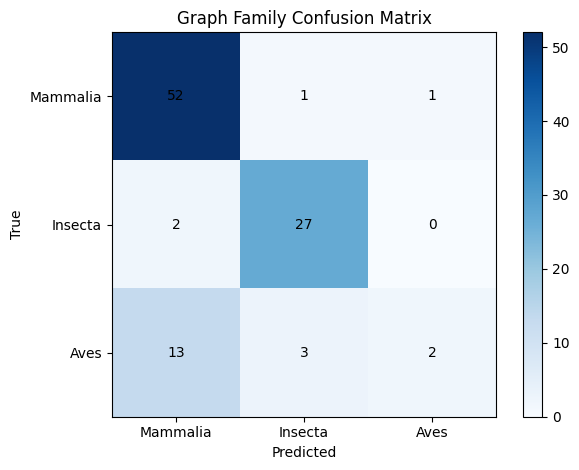

In [206]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

y_pred, y_true = evaluate_model(model, test_loader, device)

class_names = selected_classes
cm = plot_confusion_matrix(y_true.numpy(), y_pred.numpy(), class_names)

In [207]:
import torch

# Make sure they are on CPU
y_pred = y_pred.cpu()
y_true = y_true.cpu()

# Get indices of misclassified samples
misclassified_indices = torch.where(y_pred != y_true)[0]

print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Show details
for idx in misclassified_indices:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    print(test_dataset[idx].keys)

Number of misclassified samples: 20
<bound method BaseData.keys of Data(x=[7, 1], edge_index=[2, 1], y=[1])>
<bound method BaseData.keys of Data(x=[24, 1], edge_index=[2, 32], y=[1])>
<bound method BaseData.keys of Data(x=[8, 1], edge_index=[2, 28], y=[1])>
<bound method BaseData.keys of Data(x=[22, 1], edge_index=[2, 10], y=[1])>
<bound method BaseData.keys of Data(x=[10, 1], edge_index=[2, 16], y=[1])>
<bound method BaseData.keys of Data(x=[151, 1], edge_index=[2, 1554], y=[1])>
<bound method BaseData.keys of Data(x=[8, 1], edge_index=[2, 14], y=[1])>
<bound method BaseData.keys of Data(x=[22, 1], edge_index=[2, 64], y=[1])>
<bound method BaseData.keys of Data(x=[7, 1], edge_index=[2, 12], y=[1])>
<bound method BaseData.keys of Data(x=[29, 1], edge_index=[2, 28], y=[1])>
<bound method BaseData.keys of Data(x=[9, 1], edge_index=[2, 21], y=[1])>
<bound method BaseData.keys of Data(x=[11, 1], edge_index=[2, 38], y=[1])>
<bound method BaseData.keys of Data(x=[21, 1], edge_index=[2, 107],

C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


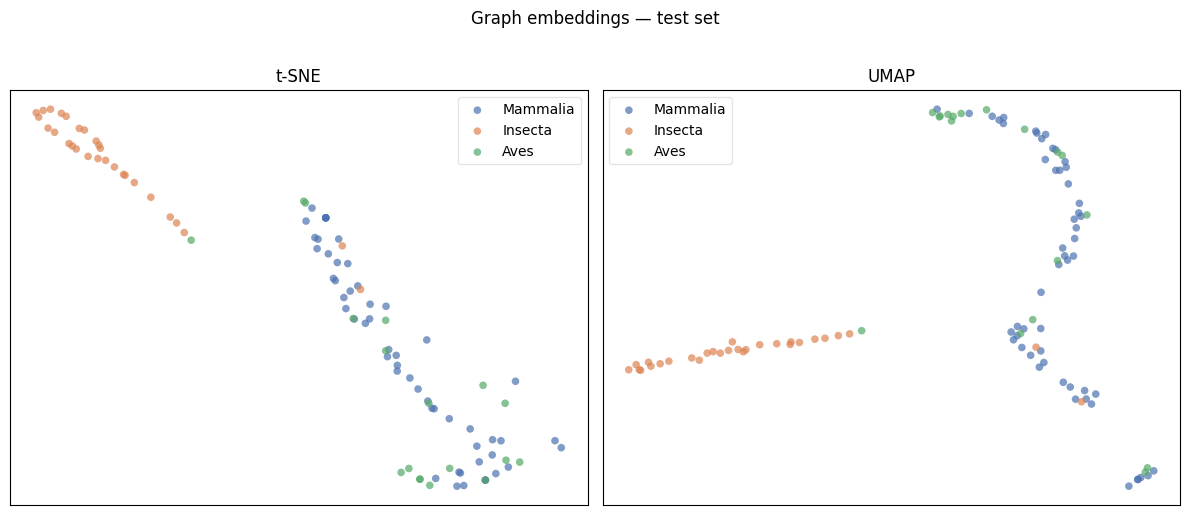

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# 1. Extract embeddings from your trained model
model.eval()
embeddings = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        emb = model.forward(batch)
        embeddings.append(emb.cpu().numpy())
        labels.append(batch.y.cpu().numpy())

embeddings = np.concatenate(embeddings, axis=0)  # shape: (N, hidden_dim)
labels = np.concatenate(labels, axis=0)          # shape: (N,)

class_names = ['Mammalia', 'Insecta', 'Aves']
colors = ['#4C72B0', '#DD8452', '#55A868']

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_coords = tsne.fit_transform(embeddings)

# 3. UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_coords = reducer.fit_transform(embeddings)

# 4. Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, coords, title in zip(axes, 
                              [tsne_coords, umap_coords], 
                              ['t-SNE', 'UMAP']):
    for i, (name, color) in enumerate(zip(class_names, colors)):
        mask = labels == i
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=name, color=color,
                   alpha=0.7, s=30, edgecolors='none')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(framealpha=0.5)

plt.suptitle('Graph embeddings — test set', y=1.02)
plt.tight_layout()
plt.savefig('embeddings.pdf', bbox_inches='tight')
plt.show()

In [218]:
print(embeddings[0])
print(test_dataset[0])

[ 0.83198816 -0.10801359 -0.41947013]
Data(x=[16, 1], edge_index=[2, 23], y=[1])
